In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/metadata.csv")

print(df.shape)
df.head()

(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


In [4]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [15]:
# Convert to numeric first
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Proper fill (NO inplace)
df['age'] = df['age'].fillna(df['age'].median())

df['sex'] = df['sex'].fillna('unknown')

# Verify again
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age              0
sex              0
localization     0
label            0
image_path       0
label_encoded    0
dtype: int64

In [6]:
label_map = {
    'mel': 'melanoma',
    'nv': 'nevus',
    'bcc': 'basal cell carcinoma',
    'akiec': 'actinic keratosis',
    'bkl': 'benign keratosis',
    'df': 'dermatofibroma',
    'vasc': 'vascular lesion'
}

df['label'] = df['dx'].map(label_map)

df[['dx','label']].head()

,dx,label
0,bkl,benign keratosis
1,bkl,benign keratosis
2,bkl,benign keratosis
3,bkl,benign keratosis
4,bkl,benign keratosis


In [7]:
selected_classes = [
    'nevus',
    'melanoma',
    'benign keratosis',
    'basal cell carcinoma',
    'actinic keratosis'
]

df = df[df['label'].isin(selected_classes)]

print(df['label'].value_counts())

label
nevus                   6705
melanoma                1113
benign keratosis        1099
basal cell carcinoma     514
actinic keratosis        327
Name: count, dtype: int64


In [8]:
df['image_path'] = df['image_id'].apply(
    lambda x: "../data/raw/images/" + x + ".jpg"
)

df[['image_id','image_path']].head()

,image_id,image_path
0,ISIC_0027419,../data/raw/images/ISIC_0027419.jpg
1,ISIC_0025030,../data/raw/images/ISIC_0025030.jpg
2,ISIC_0026769,../data/raw/images/ISIC_0026769.jpg
3,ISIC_0025661,../data/raw/images/ISIC_0025661.jpg
4,ISIC_0031633,../data/raw/images/ISIC_0031633.jpg


In [9]:
df = df[df['image_path'].apply(os.path.exists)]

print("Remaining images:", len(df))

Remaining images: 9758


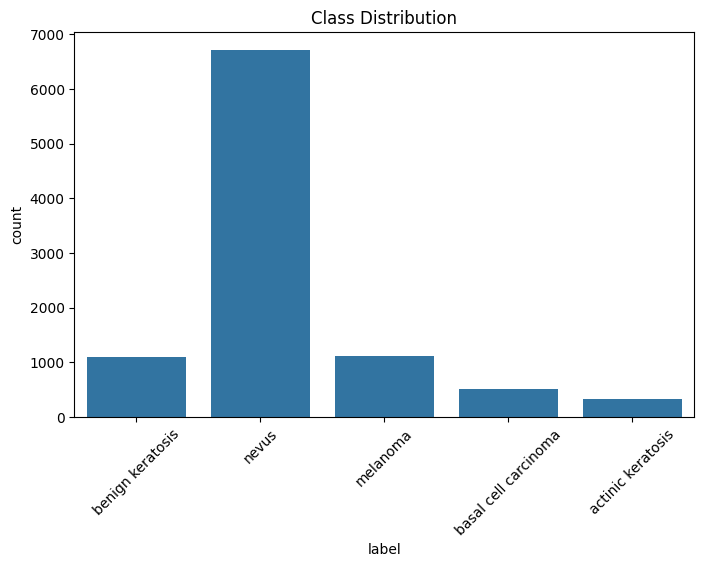

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='label')
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

In [12]:
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain Distribution:\n", train_df['label'].value_counts())

Train: (6830, 9)
Val: (1464, 9)
Test: (1464, 9)

Train Distribution:
 label
nevus                   4693
melanoma                 779
benign keratosis         769
basal cell carcinoma     360
actinic keratosis        229
Name: count, dtype: int64


In [13]:
train_df.to_csv("../data/processed/train.csv", index=False)
val_df.to_csv("../data/processed/val.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

print("Data saved successfully ✅")

Data saved successfully ✅


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'actinic keratosis': np.int64(0), 'basal cell carcinoma': np.int64(1), 'benign keratosis': np.int64(2), 'melanoma': np.int64(3), 'nevus': np.int64(4)}


In [16]:
print(df['image_path'].head())

# check if all paths exist
invalid = df[~df['image_path'].apply(os.path.exists)]
print("Invalid paths:", len(invalid))

0    ../data/raw/images/ISIC_0027419.jpg
1    ../data/raw/images/ISIC_0025030.jpg
2    ../data/raw/images/ISIC_0026769.jpg
3    ../data/raw/images/ISIC_0025661.jpg
4    ../data/raw/images/ISIC_0031633.jpg
Name: image_path, dtype: str
Invalid paths: 0


In [17]:
print(df['label'].value_counts())

label
nevus                   6705
melanoma                1113
benign keratosis        1099
basal cell carcinoma     514
actinic keratosis        327
Name: count, dtype: int64


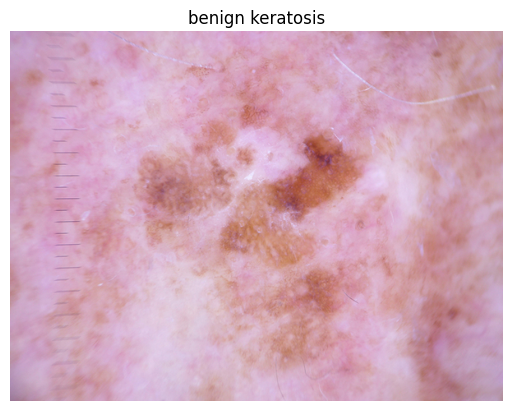

In [18]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(df.iloc[0]['image_path'])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(df.iloc[0]['label'])
plt.axis('off')
plt.show()